# Librerías

In [1]:
import os
import numpy as np
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl

### 1. Lectura de datos

Leemos los datos

In [2]:
hcc1_ann = sc.read_10x_mtx("data/GSE166635_RAW/GSM5076749_HCC1")

Coste lectura: 1m 14s - 27s

In [3]:
# Tamaño 16077 x 33694 (barcode x feature / células x genes)
hcc1_ann

AnnData object with n_obs × n_vars = 16077 × 33694
    var: 'gene_ids', 'feature_types'

In [4]:
print(hcc1_ann.obs)
print(hcc1_ann.var)

Empty DataFrame
Columns: []
Index: [AAACCCAAGAAGAACG-1, AAACCCAAGCAACAAT-1, AAACCCAAGCATCTTG-1, AAACCCAAGCTGAGTG-1, AAACCCACAAGGGCAT-1, AAACCCACAGCTGAAG-1, AAACCCACATAACGGG-1, AAACCCAGTAGCTGCC-1, AAACCCAGTATAGGAT-1, AAACCCAGTATGGGAC-1, AAACCCAGTCAACACT-1, AAACCCAGTGTCTTCC-1, AAACCCAGTTAAGGAT-1, AAACCCAGTTTCACTT-1, AAACCCATCAACTGAC-1, AAACCCATCAAGTTGC-1, AAACCCATCAGCATTG-1, AAACCCATCGTGCATA-1, AAACCCATCTGAGGTT-1, AAACCCATCTTGATTC-1, AAACGAAAGAGCAGCT-1, AAACGAACAACGATTC-1, AAACGAACAATTGCGT-1, AAACGAACACACCTAA-1, AAACGAAGTTAGGGTG-1, AAACGAAGTTTACGTG-1, AAACGAATCCATGATG-1, AAACGAATCGATTTCT-1, AAACGAATCTACGGTA-1, AAACGAATCTATCGGA-1, AAACGAATCTGACGCG-1, AAACGCTAGGCGTCCT-1, AAACGCTAGGTGGGTT-1, AAACGCTAGTGCTACT-1, AAACGCTCAAACACGG-1, AAACGCTCAACGGTAG-1, AAACGCTCAAGCGGAT-1, AAACGCTCACCTGATA-1, AAACGCTCACTACACA-1, AAACGCTCACTGTCGG-1, AAACGCTCAGAAGCTG-1, AAACGCTCAGTAGAAT-1, AAACGCTGTAGTGGCA-1, AAACGCTGTCACTCGG-1, AAACGCTGTTAGGGTG-1, AAACGCTGTTCGGCGT-1, AAACGCTGTTTATGCG-1, AAACGCTTCCGTAATG-1, AAAC

In [5]:
print(hcc1_ann.X)

<Compressed Sparse Column sparse matrix of dtype 'float32'
	with 41342896 stored elements and shape (16077, 33694)>
  Coords	Values
  (275, 3)	1.0
  (863, 3)	1.0
  (913, 3)	1.0
  (1396, 3)	1.0
  (2698, 3)	1.0
  (5135, 3)	1.0
  (5314, 3)	1.0
  (5383, 3)	1.0
  (5680, 3)	1.0
  (6483, 3)	1.0
  (6936, 3)	1.0
  (7891, 3)	1.0
  (7996, 3)	1.0
  (8013, 3)	1.0
  (9824, 3)	1.0
  (10326, 3)	1.0
  (11600, 3)	1.0
  (12048, 3)	1.0
  (12080, 3)	1.0
  (15432, 3)	1.0
  (16063, 3)	1.0
  (305, 6)	1.0
  (347, 6)	1.0
  (1093, 6)	1.0
  (2701, 6)	1.0
  :	:
  (14852, 33691)	1.0
  (14879, 33691)	2.0
  (14913, 33691)	1.0
  (14978, 33691)	1.0
  (15142, 33691)	1.0
  (15174, 33691)	2.0
  (15188, 33691)	1.0
  (15248, 33691)	1.0
  (15281, 33691)	1.0
  (15287, 33691)	1.0
  (15344, 33691)	1.0
  (15403, 33691)	1.0
  (15416, 33691)	1.0
  (15472, 33691)	1.0
  (15502, 33691)	1.0
  (15512, 33691)	1.0
  (15625, 33691)	1.0
  (15748, 33691)	1.0
  (15838, 33691)	1.0
  (15898, 33691)	1.0
  (15904, 33691)	1.0
  (15940, 33691)	1.0

### 2. Limpieza de datos

Pasamos a limpiar las muestras que no tienen sentido, lo que queremos obtener al final:

    - células con número de genes entre 200 y 7000
    - células con proporción de mitocondria menor de 20%
    - genes expresados en 4 células o más

In [3]:
# Añadimos columna a var paragenes mitocondriales, MT- para referir a genes mitocondriales de humanos
hcc1_ann.var["mt"] = hcc1_ann.var_names.str.startswith("MT-")

# Calculamos métricas de control de calidad, añadimos la variable que nos interesa "mt"
sc.pp.calculate_qc_metrics(hcc1_ann, qc_vars=["mt"], inplace=True)
# Se modifica directamente la matriz, añadiendo columnas de métricas

In [4]:
hcc1_ann.obs

,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt
AAACCCAAGAAGAACG-1,1729,7.455877,5173.0,8.551401,36.149236,47.322637,58.901991,73.864295,413.0,6.025866,7.983762
AAACCCAAGCAACAAT-1,3782,8.238273,13257.0,9.492356,25.571396,34.917402,46.360413,61.597647,905.0,6.809039,6.826582
AAACCCAAGCATCTTG-1,2750,7.919720,9418.0,9.150484,29.507326,41.293268,53.695052,68.273519,721.0,6.582025,7.655553
AAACCCAAGCTGAGTG-1,1448,7.278629,4960.0,8.509362,37.923387,50.383065,64.193548,79.979839,257.0,5.552959,5.181451
AAACCCACAAGGGCAT-1,2080,7.640604,8340.0,9.028938,40.671463,50.539568,61.486811,76.294964,314.0,5.752573,3.764988
...,...,...,...,...,...,...,...,...,...,...,...
TTTGTTGTCAGGTGTT-1,735,6.601230,1366.0,7.220374,32.723280,45.461201,60.395315,82.796486,76.0,4.343805,5.563690
TTTGTTGTCCAAATGC-1,2014,7.608374,5809.0,8.667336,34.962988,45.205715,56.326390,70.511276,448.0,6.107023,7.712171
TTTGTTGTCTAACGCA-1,2156,7.676474,5918.0,8.685923,36.059480,44.237918,53.531599,67.641095,766.0,6.642487,12.943562
TTTGTTGTCTCAGGCG-1,2961,7.993620,15018.0,9.617071,64.862165,69.383407,73.944600,80.550007,7243.0,8.887929,48.228790


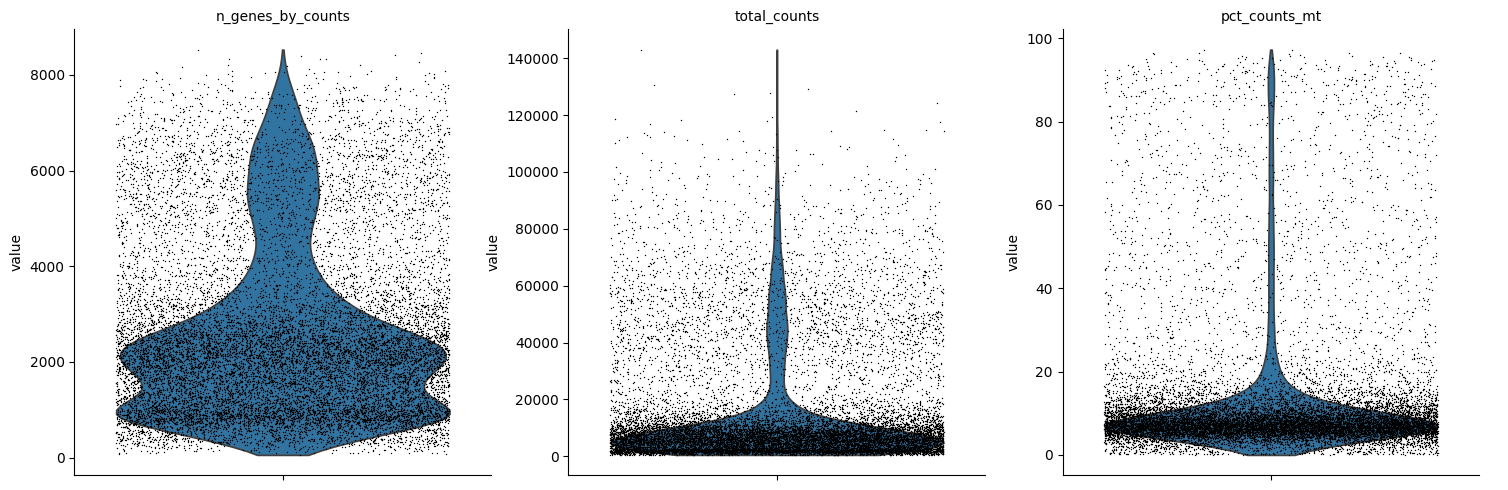

In [11]:
sc.pl.violin(
    hcc1_ann,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)

En las gráficas que se muestran previamente, podemos ver la distribución de datos y dónde hay más densidad, esto puede ser una **clave** para determinar los umbrales de filtrado.

<Axes: xlabel='pct_counts_mt', ylabel='Count'>

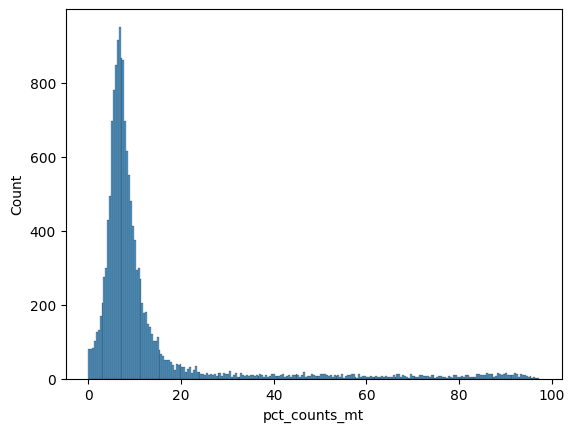

In [15]:
sns.histplot(hcc1_ann.obs["pct_counts_mt"])

En el histograma se puede comprobar que el valor de filtrado de 20% de proporción mitocondria (ligeramente permisivo) puede ser lógico, dado que hay una gran concentración de datos que están en esa zona.

#### 2.1. Filtrado por número de genes

Miramos principalmente el "**n_genes_by_counts**", que es la métrica que cuenta el número de genes que tiene mínimo un *count* (existe) en la célula. Es decir, número de genes que tiene una célula. También hay que reducir los genes que no tienen un número mínimo de apariciones en células.

In [4]:
hcc1_filter_gen_counts = hcc1_ann[(hcc1_ann.obs["n_genes_by_counts"] >= 200) & (hcc1_ann.obs["n_genes_by_counts"] <= 7000)].copy()

# También se podría hacer:
#sc.pp.filter_cells(hcc1_filter_gen_counts, min_genes=200)
#sc.pp.filter_cells(hcc1_filter_gen_counts, max_genes=7000)

sc.pp.filter_genes(hcc1_filter_gen_counts, min_cells=4) # Filtramos genes que no estén expresado en al menos 4 células

# 15609 células y 21815 genes resultantes
print(hcc1_filter_gen_counts.obs["n_genes_by_counts"])

AAACCCAAGAAGAACG-1    1729
AAACCCAAGCAACAAT-1    3782
AAACCCAAGCATCTTG-1    2750
AAACCCAAGCTGAGTG-1    1448
AAACCCACAAGGGCAT-1    2080
                      ... 
TTTGTTGTCAGGTGTT-1     735
TTTGTTGTCCAAATGC-1    2014
TTTGTTGTCTAACGCA-1    2156
TTTGTTGTCTCAGGCG-1    2961
TTTGTTGTCTGGTGGC-1    5943
Name: n_genes_by_counts, Length: 15609, dtype: int64


In [5]:
hcc1_filter_gen_counts.var

,gene_ids,feature_types,mt,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts,n_cells
RP11-34P13.7,ENSG00000238009,Gene Expression,False,21,0.001306,0.001305,99.869379,21.0,3.091043,17
RP11-34P13.9,ENSG00000241599,Gene Expression,False,9,0.000560,0.000560,99.944019,9.0,2.302585,8
FO538757.2,ENSG00000279457,Gene Expression,False,1205,0.081607,0.078448,92.504821,1312.0,7.180070,1084
AP006222.2,ENSG00000228463,Gene Expression,False,2027,0.152640,0.142055,87.391926,2454.0,7.805882,1798
RP4-669L17.10,ENSG00000237094,Gene Expression,False,93,0.005971,0.005954,99.421534,96.0,4.574711,77
...,...,...,...,...,...,...,...,...,...,...
AC007325.4,ENSG00000278817,Gene Expression,False,1228,0.097655,0.093176,92.361759,1570.0,7.359468,1035
AL354822.1,ENSG00000278384,Gene Expression,False,990,0.073770,0.071176,93.842135,1186.0,7.079185,859
AC004556.1,ENSG00000276345,Gene Expression,False,2150,0.170119,0.157105,86.626858,2735.0,7.914252,1920
AC233755.2,ENSG00000277856,Gene Expression,False,8,0.001368,0.001367,99.950239,22.0,3.135494,8


In [ ]:
# Miramos los datos que han sido filtrados
hcc1_gen_counts_left = hcc1_ann[(hcc1_ann.obs["n_genes_by_counts"] < 200) | (hcc1_ann.obs["n_genes_by_counts"] > 7000)]

hcc1_lower_bound_gen_counts = hcc1_ann[hcc1_ann.obs["n_genes_by_counts"] < 200]

hcc1_upper_bound_gen_counts = hcc1_ann[hcc1_ann.obs["n_genes_by_counts"] > 7000]

# Crear fichero csv con los datos para analizar
#hcc1_gen_counts_left.obs.to_csv("hcc1_gen_counts_left_obs.csv")
#hcc1_lower_bound_gen_counts.obs.to_csv("hcc1_lower_bound_gen_counts.csv")
#hcc1_upper_bound_gen_counts.obs.to_csv("hcc1_upper_bound_gen_counts.csv")

El límite para abajo se puede fijar a 200, los datos no sirven si intentamos bajar el umbral, no obstante, se puede mirar el límite por arriba, comprobar si se puede ser más permisivo.

Se va a probar con 7200 y 7500 como extremo, miramos los datos entre 7000 - 7200 y 7200 - 7500

In [ ]:
hcc1_upper_bound_A = hcc1_ann[(hcc1_ann.obs["n_genes_by_counts"] > 7000) & (hcc1_ann.obs["n_genes_by_counts"] < 7201)]
hcc1_upper_bound_B = hcc1_ann[(hcc1_ann.obs["n_genes_by_counts"] > 7200) & (hcc1_ann.obs["n_genes_by_counts"] < 7501)]

#hcc1_upper_bound_A.obs.to_csv("hcc1_upper_bound_A.csv")
#hcc1_upper_bound_B.obs.to_csv("hcc1_upper_bound_B.csv")

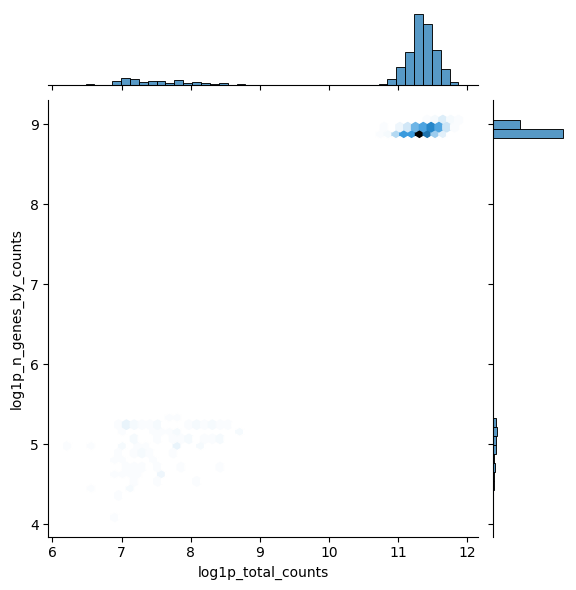

In [9]:
sns.jointplot(
    data=hcc1_gen_counts_left.obs,
    x="log1p_total_counts",
    y="log1p_n_genes_by_counts",
    kind="hex",
)

<Axes: xlabel='pct_counts_mt', ylabel='Count'>

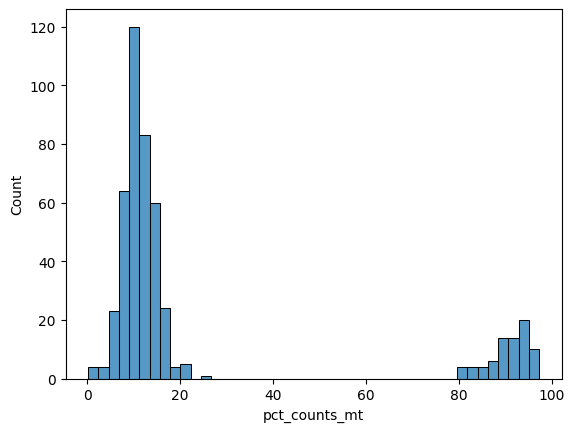

In [10]:
sns.histplot(hcc1_gen_counts_left.obs["pct_counts_mt"])

Gran parte de los datos filtrados son datos con más de 7000 genes, lo que significa que en esta recolección hay varias muestras con posiblemente más de una célula.

Los datos menos frecuentes tienen una proporción de mitocondria exagerada (80 - 90%). Si se analiza los datos, se puede ver que el "total_counts_mt" (cuenta de genes MT) es un valor cercano a "total_counts" (cuenta de la célula), básicamente indica que estas células están dañadas o son de baja calidad.

#### 2.2. Filtrado por mitocondria

In [5]:
hcc1_filtered = hcc1_filter_gen_counts[(hcc1_filter_gen_counts.obs["pct_counts_mt"] <= 20)]

# 13883 muestras resultantes
hcc1_filtered.obs

,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt
AAACCCAAGAAGAACG-1,1729,7.455877,5173.0,8.551401,36.149236,47.322637,58.901991,73.864295,413.0,6.025866,7.983762
AAACCCAAGCAACAAT-1,3782,8.238273,13257.0,9.492356,25.571396,34.917402,46.360413,61.597647,905.0,6.809039,6.826582
AAACCCAAGCATCTTG-1,2750,7.919720,9418.0,9.150484,29.507326,41.293268,53.695052,68.273519,721.0,6.582025,7.655553
AAACCCAAGCTGAGTG-1,1448,7.278629,4960.0,8.509362,37.923387,50.383065,64.193548,79.979839,257.0,5.552959,5.181451
AAACCCACAAGGGCAT-1,2080,7.640604,8340.0,9.028938,40.671463,50.539568,61.486811,76.294964,314.0,5.752573,3.764988
...,...,...,...,...,...,...,...,...,...,...,...
TTTGTTGTCAGCATTG-1,5380,8.590630,30589.0,10.328428,33.750695,43.927556,54.058649,66.422570,3190.0,8.068089,10.428585
TTTGTTGTCAGGTGTT-1,735,6.601230,1366.0,7.220374,32.723280,45.461201,60.395315,82.796486,76.0,4.343805,5.563690
TTTGTTGTCCAAATGC-1,2014,7.608374,5809.0,8.667336,34.962988,45.205715,56.326390,70.511276,448.0,6.107023,7.712171
TTTGTTGTCTAACGCA-1,2156,7.676474,5918.0,8.685923,36.059480,44.237918,53.531599,67.641095,766.0,6.642487,12.943562


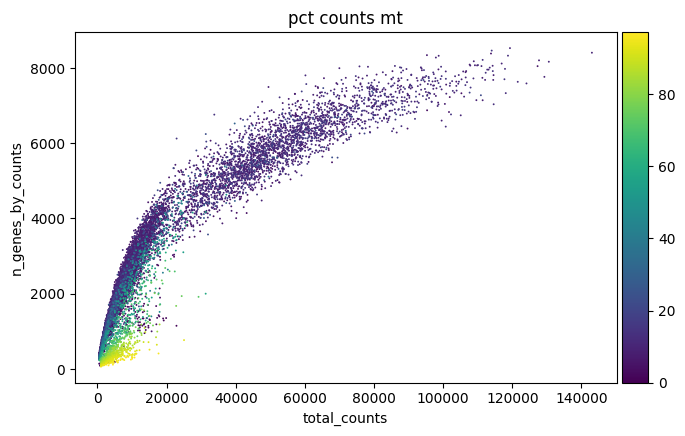

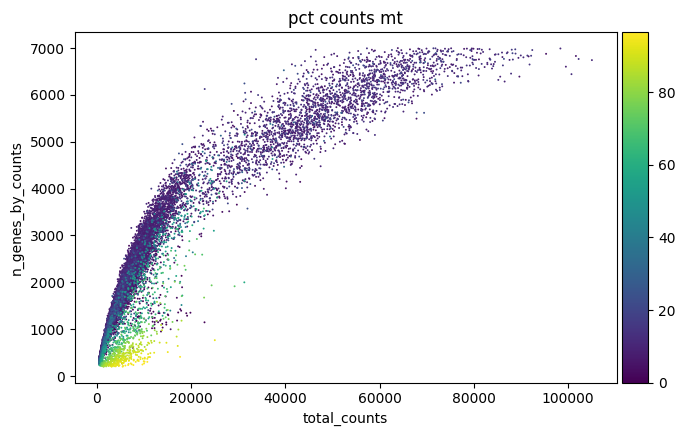

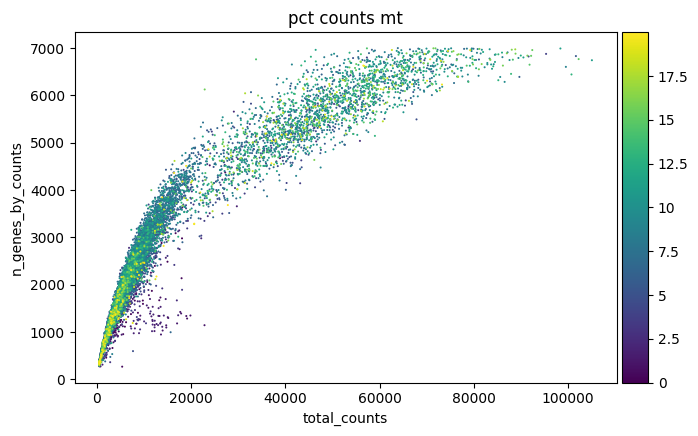

In [15]:
sc.pl.scatter(hcc1_ann, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

sc.pl.scatter(hcc1_filter_gen_counts, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

sc.pl.scatter(hcc1_filtered, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

El primer filtrado hace un corte por arriba y abajo del total de las muestras, luego en el segundo filtrado se eliminan bastantes datos de la parte inferior izquierda, en comparación con las primeras gráficas.

Los datos que se quitan en el segundo cribado tienen menor total_counts, número total de cuentas para una célula y n_genes_by_counts, es decir, no están muy expresados en comparación con el conjunto total (se quitan las células de baja calidad, mucha mitocondria en comparación con la "cantidad" de célula).

#### 2.3. Doublets

En técnicas modernas de secuenciación de células individuales (scRNA-seq), un doublet ocurre cuando dos células quedan atrapadas juntas en la misma gota o pocillo durante el aislamiento. El secuenciador las lee como si fueran una sola célula, lo que puede causar errores en los datos si no se filtran computacionalmente.

In [ ]:
hcc1_filter_A = hcc1_ann[(hcc1_ann.obs["n_genes_by_counts"] >= 200) & (hcc1_ann.obs["n_genes_by_counts"] <= 7200)]

hcc1_filter_B = hcc1_ann[(hcc1_ann.obs["n_genes_by_counts"] >= 200) & (hcc1_ann.obs["n_genes_by_counts"] <= 7500)]

# He ejecutado el scrublets con esto y no ha hecho nada. Parámetros o es que da igual.

In [ ]:
# Dejo todos los parámetros por defecto, por probar
hcc1_no_doublet = sc.pp.scrublet(hcc1_filtered, copy=True)

# 10m

In [ ]:
hcc1_no_doublet_A = sc.pp.scrublet(hcc1_upper_bound_A, copy=True)

In [15]:
hcc1_no_doublet_B = sc.pp.scrublet(hcc1_upper_bound_B, copy=True)

In [14]:
hcc1_no_doublet_A.obs

,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,doublet_score,predicted_doublet
AAACCCATCAGCATTG-1,7033,8.858511,56426.0,10.940703,34.565626,47.176833,56.922341,67.732960,3225.0,8.078999,5.715450,0.078788,False
AAACGCTAGGTGGGTT-1,7109,8.869258,73873.0,11.210116,36.450395,46.255059,56.712195,69.125391,6815.0,8.827028,9.225292,0.078788,False
AAACGCTTCTGACAGT-1,7071,8.863899,65883.0,11.095651,37.773022,47.673907,57.338008,69.142267,6241.0,8.739056,9.472854,0.059406,False
AACCCAAGTCCTCCTA-1,7005,8.854522,81870.0,11.312901,39.816783,51.600098,62.744595,73.884207,7636.0,8.940760,9.326982,0.028754,False
AAGTGAATCGGCTATA-1,7047,8.860499,80433.0,11.295193,41.475514,52.425000,62.619820,73.992018,9540.0,9.163354,11.860804,0.036232,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTGGGATGTGCGGCTT-1,7056,8.861775,69885.0,11.154620,39.224440,50.960864,60.878586,71.484582,5613.0,8.633018,8.031766,0.046025,False
TTGGGTACACTCGATA-1,7051,8.861067,82430.0,11.319716,40.049739,53.987626,64.602693,74.608759,7035.0,8.858795,8.534514,0.046025,False
TTTACGTTCTGGTGGC-1,7186,8.880029,69830.0,11.153833,34.008306,45.791207,56.510096,68.324502,6047.0,8.707483,8.659602,0.078788,False
TTTAGTCAGCTGGAGT-1,7068,8.863474,63925.0,11.065481,37.863121,50.075870,59.084865,69.515839,6083.0,8.713418,9.515839,0.059406,False


In [16]:
hcc1_no_doublet_B.obs

,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,doublet_score,predicted_doublet
AAACCCATCAACTGAC-1,7236,8.886962,69085.0,11.143107,42.505609,52.706087,61.738438,71.744952,11185.0,9.322418,16.190201,0.057851,False
AAAGGGCGTATTCTCT-1,7258,8.889997,69982.0,11.156008,33.928725,44.107056,54.936984,67.881741,9600.0,9.169622,13.717813,0.073171,False
AAAGTGAAGTACTGGG-1,7474,8.919319,78647.0,11.272738,36.668913,46.678195,57.806401,70.338347,8648.0,9.065199,10.995969,0.057851,False
AACCAACCATCACAGT-1,7463,8.917847,78177.0,11.266744,37.498241,49.001625,59.456106,70.048736,8710.0,9.072342,11.141384,0.057851,False
AACCCAAAGCCTCAAT-1,7339,8.901094,95962.0,11.471718,44.585357,56.939205,66.510702,75.816469,13938.0,9.542446,14.524499,0.037975,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTGGTTTCACGGTCTG-1,7238,8.887238,106054.0,11.571713,43.500481,57.036981,66.696211,76.623230,12116.0,9.402365,11.424369,0.095238,False
TTGGTTTTCCGTCACT-1,7347,8.902183,64439.0,11.073490,38.149257,48.535825,57.716600,68.157482,5120.0,8.541105,7.945499,0.037975,False
TTTCCTCTCCCTTTGG-1,7499,8.922658,87510.0,11.379519,37.182036,45.746772,55.499943,67.602560,10062.0,9.216620,11.498115,0.046595,False
TTTGATCCATGCAGCC-1,7376,8.906122,59084.0,10.986732,35.116106,43.529551,52.987272,64.712951,10828.0,9.289983,18.326450,0.095238,False


In [12]:
hcc1_no_doublet.obs

,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,doublet_score,predicted_doublet
AAACCCAAGAAGAACG-1,1729,7.455877,5173.0,8.551401,36.149236,47.322637,58.901991,73.864295,413.0,6.025866,7.983762,0.074709,False
AAACCCAAGCAACAAT-1,3782,8.238273,13257.0,9.492356,25.571396,34.917402,46.360413,61.597647,905.0,6.809039,6.826582,0.091731,False
AAACCCAAGCATCTTG-1,2750,7.919720,9418.0,9.150484,29.507326,41.293268,53.695052,68.273519,721.0,6.582025,7.655553,0.030190,False
AAACCCAAGCTGAGTG-1,1448,7.278629,4960.0,8.509362,37.923387,50.383065,64.193548,79.979839,257.0,5.552959,5.181451,0.041187,False
AAACCCACAAGGGCAT-1,2080,7.640604,8340.0,9.028938,40.671463,50.539568,61.486811,76.294964,314.0,5.752573,3.764988,0.008504,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTTGTCAGCATTG-1,5380,8.590630,30589.0,10.328428,33.750695,43.927556,54.058649,66.422570,3190.0,8.068089,10.428585,0.027670,False
TTTGTTGTCAGGTGTT-1,735,6.601230,1366.0,7.220374,32.723280,45.461201,60.395315,82.796486,76.0,4.343805,5.563690,0.009822,False
TTTGTTGTCCAAATGC-1,2014,7.608374,5809.0,8.667336,34.962988,45.205715,56.326390,70.511276,448.0,6.107023,7.712171,0.025363,False
TTTGTTGTCTAACGCA-1,2156,7.676474,5918.0,8.685923,36.059480,44.237918,53.531599,67.641095,766.0,6.642487,12.943562,0.016619,False


No hay diferencia, dejo los datos filtrados sin ejecutar **scrublet()**.

#### 2.4. Normalización

Dejamos los datos en un intervalo más manejable.

In [6]:
# Saving count data
hcc1_filtered.layers["counts"] = hcc1_filtered.X.copy()

C:\Users\Usuario\AppData\Local\Temp\ipykernel_22252\2911544399.py:2: ImplicitModificationWarning: Setting element `.layers['counts']` of view, initializing view as actual.
  hcc1_filtered.layers["counts"] = hcc1_filtered.X.copy()


In [7]:
hcc1_normalized = hcc1_filtered.copy()

# Normalización (mediana del número total de cuentas)
sc.pp.normalize_total(hcc1_normalized)

# Transformación logarítmica
sc.pp.log1p(hcc1_normalized)

In [16]:
print(hcc1_normalized.X)

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 35523923 stored elements and shape (13883, 21815)>
  Coords	Values
  (0, 19)	0.8528058528900146
  (0, 28)	0.8528058528900146
  (0, 79)	0.8528058528900146
  (0, 86)	0.8528058528900146
  (0, 110)	1.3062878847122192
  (0, 136)	1.3062878847122192
  (0, 142)	3.2800910472869873
  (0, 144)	0.8528058528900146
  (0, 156)	0.8528058528900146
  (0, 160)	0.8528058528900146
  (0, 188)	0.8528058528900146
  (0, 192)	0.8528058528900146
  (0, 197)	0.8528058528900146
  (0, 200)	1.6171406507492065
  (0, 247)	0.8528058528900146
  (0, 250)	0.8528058528900146
  (0, 251)	1.3062878847122192
  (0, 254)	0.8528058528900146
  (0, 268)	1.3062878847122192
  (0, 269)	0.8528058528900146
  (0, 290)	1.3062878847122192
  (0, 304)	0.8528058528900146
  (0, 308)	2.9880573749542236
  (0, 309)	2.7605433464050293
  (0, 310)	2.9880573749542236
  :	:
  (13882, 21756)	0.1813645213842392
  (13882, 21757)	0.1813645213842392
  (13882, 21758)	0.4678489863872528
  (13882, 2

La normalización que se usa es el que por defecto ofrece scanpy, donde se le divide por la mediana del total de cuentas de células.

Una vez tenemos los datos normalizados, hay que reducir la dimensión, escogiendo solo los genes más informativos (más variación), más o menos 2000.

In [11]:
hcc1_high_var = hcc1_normalized.copy()

Se va a probar las distintas implementaciones para escoger los genes con más variación: '*seurat*', '*cell_ranger*', '*seurat_v3*' y '*seurat_v3_paper*'.

Las dos primeras implementaciones escogen los genes basado en una **dispersión normalizada**, que se obtiene agrupando los genes en base a su expresión media en un '*bin*'. Para cada '*bin*' se **escala** la dispersión de los genes con la media y desviación estándar de las dispersiones de los genes dentro '*bin*'. Finalmente se escogen los genes designados de cada '*bin*'.

La diferencia entre '*seurat*' y '*cell_ranger*' es que '*seurat*' calcula el z-score ($z = \frac{x - \mu}{\sigma}$) y '*cell_ranger*' computa la diferencia absoluta entre la dispersión y dispersión mediana de cada bin, dividido entre la desviación absoluta de la mediana (MAD).

Para '*seurat_v3*' y '*seurat_v3_paper*' esperan datos sin logaritmizar a diferencia de los anteriores y devuelven una varianza normalizada para cada gen. Los datos se estandarizan con una desviación estándar regularizada, después la varianza normalizada se calcula como la varianza de cada gen. No hay diferencia entre los dos si **batch_key=None**

Estas técnicas utilizadas evitan escoger directamente los genes con más varianza, dado que la varianza puede ser acumulada a base de un mayor número de expresiones de un gen. Se puede usar un criterio más justo para conseguir los genes con más información.

In [12]:
sc.pp.highly_variable_genes(hcc1_high_var, n_top_genes=2000, flavor='cell_ranger')    # flavor params: 'seurat', 'cell_ranger'

In [14]:
sc.pp.highly_variable_genes(hcc1_filtered, layer='counts', n_top_genes=2000, flavor='seurat_v3')    # flavor params: 'seurat_v3', 'seurat_v3_paper'

##### 2.4.1. Seurat

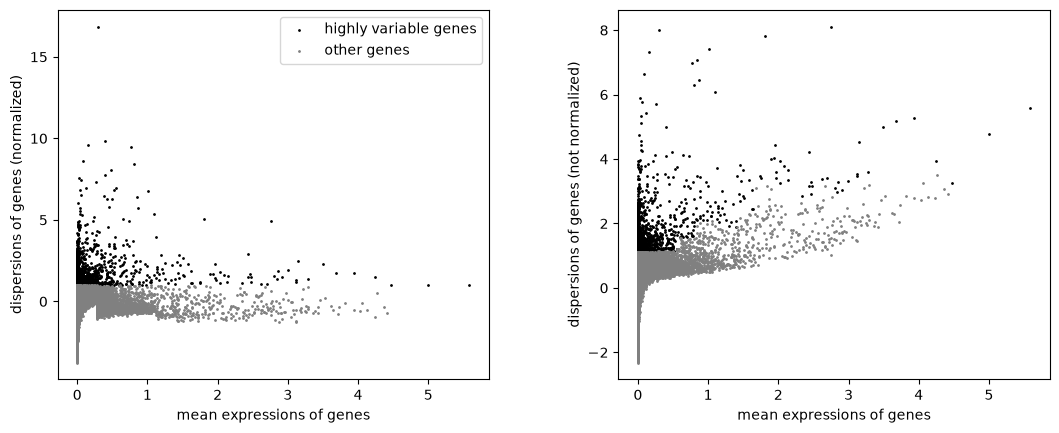

In [18]:
sc.pl.highly_variable_genes(hcc1_high_var)

Se puede ver una clara línea de separación entre los genes más informativos y no, puede no ser muy apto porque deja pasar algún dato que está muy expresado. No es muy robusto.

##### 2.4.2. Cell Ranger

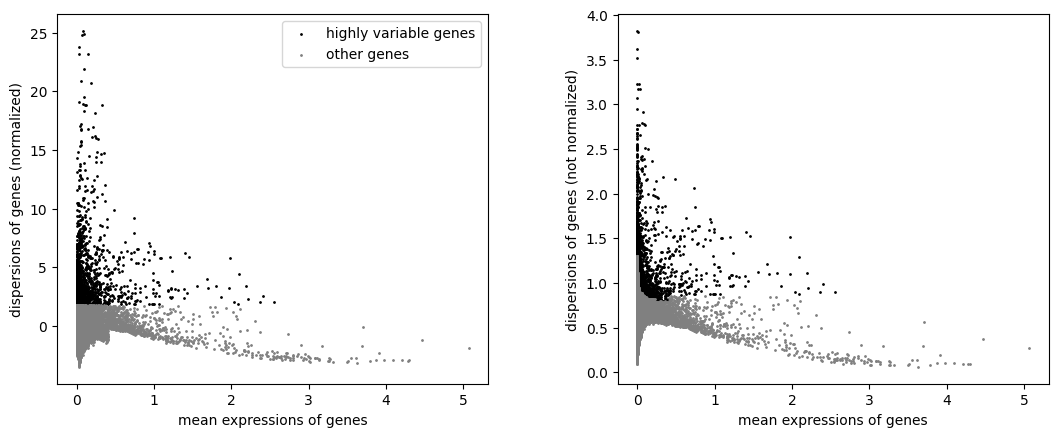

In [10]:
sc.pl.highly_variable_genes(hcc1_high_var)

Se parece de alguna forma al anterior, pero parece más robusto frente al ruido y tiene métricas distintas al ser dos formas de cálculo distintos.

##### 2.4.3. Seurat v3

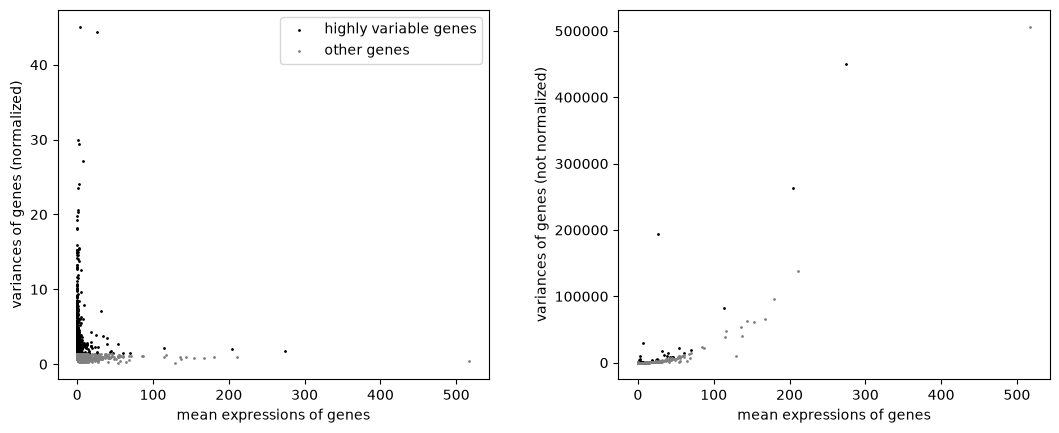

In [10]:
sc.pl.highly_variable_genes(hcc1_filtered)

Este último método parece ser el adecuado, en la gráfica de la izquierda (normalizada), se concentran los genes seleccionados en una expresión media de menor grado.

# TODO:
- Clasificar exhausted y non_exhausted
- FBA